In [1]:
!pip install gensim
!pip install opendatasets
!python -m spacy download en_core_web_lg


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 4.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
!pip install -q transformers datasets evaluate accelerate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 19.7 MB/s eta 0:00:00


In [3]:
!pip install --upgrade --force-reinstall pyarrow

  Using cached pyarrow-24.0.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.0 kB)
Using cached pyarrow-24.0.0-cp312-cp312-manylinux_2_28_x86_64.whl (48.9 MB)
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 24.0.0
    Uninstalling pyarrow-24.0.0:
      Successfully uninstalled pyarrow-24.0.0


In [4]:
import opendatasets as od
import pandas as pd
import numpy as np
import re
import string
import evaluate
import torch
import spacy
from tqdm import tqdm

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

from gensim.models import Word2Vec
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset


model_id = "roupenminassian/TwHIN-BERT-Misinformation-Classifier"
tqdm.pandas()

In [5]:
#KGAT_9e22a898763110e4579177643e19528b
od.download("https://www.kaggle.com/datasets/doanquanvietnamca/liar-dataset/")
od.download("https://www.kaggle.com/datasets/studymart/welfake-dataset-for-fake-news/data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: dmeansdream
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/doanquanvietnamca/liar-dataset


100%|██████████| 0.98M/0.98M [00:01<00:00, 910kB/s]



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: dmeansdream
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/studymart/welfake-dataset-for-fake-news


100%|██████████| 92.1M/92.1M [00:06<00:00, 15.4MB/s]


In [6]:
df = pd.read_csv("/content/welfake-dataset-for-fake-news/WELFake_Dataset.csv")
df = df.dropna()

df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
5,5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1


In [ ]:
df["context"] = df["title"] + " " + df["text"]
df = df.drop(columns=["title", "text"])

In [ ]:
df_small, _ = train_test_split(
    df,
    train_size=0.05,
    stratify=df['label'],
    random_state=393
)

In [14]:
nlp = spacy.load("en_core_web_lg")

def process_text(
    text: str,
    mask_types: set = {"PERSON", "ORG", "GPE", "LOC", "NORP", "FAC", "TIME", "DATE"},
    max_words: int = 300
) -> str:

    words = str(text).split()
    text = " ".join(words[:max_words])

    # URL
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Mask named entities and delete them
    doc = nlp(text[:100_000])
    for ent in reversed(doc.ents):
        if ent.label_ in mask_types:
            text = text[:ent.start_char] + text[ent.end_char:]

    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [10]:
df_small['context_processed'] = df_small['context'].progress_apply(process_text)

100%|██████████| 3576/3576 [02:49<00:00, 21.06it/s]


In [11]:
df_train, df_val = train_test_split(
    df_small,
    test_size=0.2,
    stratify=df_small['label'],
    random_state=393
)

In [12]:
# Word2Vec training

tokenized_docs = [text.split() for text in df_train['context_processed']]
val_tokens = [text.split() for text in df_val['context_processed']]

w2v_model = Word2Vec(
    sentences=tokenized_docs,
    vector_size=300,
    window=5,
    min_count=3,
    workers=4,
    epochs=10
)

def get_custom_doc_vector(tokens, model):
    valid_tokens = [word for word in tokens if word in model.wv.key_to_index]
    if not valid_tokens:
        return np.zeros(model.vector_size)
    return np.mean(model.wv[valid_tokens], axis=0)

X_train_w2v = np.vstack([get_custom_doc_vector(tokens, w2v_model) for tokens in tokenized_docs])
X_val_w2v = np.vstack([get_custom_doc_vector(tokens, w2v_model) for tokens in val_tokens])

lr_custom = LogisticRegression(max_iter=1000)
lr_custom.fit(X_train_w2v, df_train['label'])

scores_custom = cross_val_score(lr_custom, X_train_w2v, df_train['label'], cv=5, scoring='accuracy')
print(f"Word2Vec + LR Accuracy: {scores_custom.mean():.4f} ± {scores_custom.std():.4f}")

Word2Vec + LR Accuracy: 0.8808 ± 0.0136


In [13]:
#RF
y_train = df_train['label'].values
y_val = df_val['label'].values

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

# 2. Fit on training data and transform (Creates a Sparse Matrix)
X_train_tfidf = tfidf.fit_transform(df_train['context_processed'])

# 3. Transform validation and LIAR data (CRITICAL: Use .transform(), not .fit_transform())
X_val_tfidf = tfidf.transform(df_val['context_processed'])

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, df_train['label'])

print("\n[RF WELFake Validation Results]")
rf_val_preds = rf_model.predict(X_val_tfidf)
rf_val_probs = rf_model.predict_proba(X_val_tfidf)[:, 1] # Get probabilities for Fake class

print(f"WELFake RF Accuracy: {accuracy_score(y_val, rf_val_preds):.4f}")
print(f"WELFake RF ROC-AUC: {roc_auc_score(y_val, rf_val_probs):.4f}\n")
print("Classification Report:")
print(classification_report(y_val, rf_val_preds, target_names=["Real (0)", "Fake (1)"]))




[RF WELFake Validation Results]
WELFake RF Accuracy: 0.8785
WELFake RF ROC-AUC: 0.9471

Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.89      0.86      0.87       351
    Fake (1)       0.87      0.89      0.88       365

    accuracy                           0.88       716
   macro avg       0.88      0.88      0.88       716
weighted avg       0.88      0.88      0.88       716



In [15]:
# Embedding matrix setup

vocab_size = len(w2v_model.wv.key_to_index) + 1
embedding_dim = w2v_model.vector_size
embedding_matrix = np.zeros((vocab_size, embedding_dim))
token2idx = {}

for word, idx in w2v_model.wv.key_to_index.items():
    new_idx = idx + 1
    embedding_matrix[new_idx] = w2v_model.wv[word]
    token2idx[word] = new_idx

# Vectorize and Pad
X_train_seqs = [[token2idx[token] for token in tokens if token in token2idx] for tokens in tokenized_docs]
X_val_seqs = [[token2idx[token] for token in tokens if token in token2idx] for tokens in val_tokens]

y_train = df_train['label'].values
y_val = df_val['label'].values

train_data = [(seq, label) for seq, label in zip(X_train_seqs, y_train) if len(seq) > 0]
val_data   = [(seq, label) for seq, label in zip(X_val_seqs,   y_val)   if len(seq) > 0]

X_train_seqs, y_train = zip(*train_data)
X_val_seqs,   y_val   = zip(*val_data)

MAX_LEN = 300
X_train_pad = pad_sequences(X_train_seqs, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seqs, maxlen=MAX_LEN, padding='post', truncating='post')

y_train = np.array(y_train)
y_val   = np.array(y_val)

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False,
        mask_zero=True
    ),
    Bidirectional(LSTM(64)),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5,
    batch_size=32
)

Epoch 1/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.8709 - loss: 0.2895 - val_accuracy: 0.9358 - val_loss: 0.1678
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.9290 - loss: 0.1771 - val_accuracy: 0.9427 - val_loss: 0.1493
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.9405 - loss: 0.1436 - val_accuracy: 0.9483 - val_loss: 0.1435
Epoch 4/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - accuracy: 0.9510 - loss: 0.1220 - val_accuracy: 0.9260 - val_loss: 0.1779
Epoch 5/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.9580 - loss: 0.1092 - val_accuracy: 0.9511 - val_loss: 0.1539


In [16]:
loss, accuracy = model.evaluate(X_val_pad, y_val, verbose=0)
print(f"Welfake LSTM Loss: {loss:.4f}")
print(f"Welfake LSTM Accuracy: {accuracy:.4f}")

y_val_probs = model.predict(X_val_pad, verbose=0)
y_val_classes = (y_val_probs >= 0.5).astype(int).flatten()
print(f"LSTM ROC-AUC:{roc_auc_score(y_val, y_val_probs):.4f}\n")

print("Welfake Classification")
print(classification_report(y_val, y_val_classes, target_names=["Real (0)", "Fake (1)"]))

print("Welfake Native Confusion Matrix")
cm = confusion_matrix(y_val, y_val_classes)
print(f"TP:  {cm[0][0]:<5} | FN:  {cm[0][1]}")
print(f"FP: {cm[1][0]:<5} | TN:  {cm[1][1]}\n")


lr_val_preds = lr_custom.predict(X_val_w2v)
lr_val_acc = accuracy_score(y_val, lr_val_preds)
print(f"Welfake LR Accuracy: {lr_val_acc:.4f}\n")
print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_val, lr_val_preds):.4f}")

Welfake LSTM Loss: 0.1539
Welfake LSTM Accuracy: 0.9511
LSTM ROC-AUC:0.9856

Welfake Classification
              precision    recall  f1-score   support

    Real (0)       0.95      0.95      0.95       351
    Fake (1)       0.95      0.96      0.95       365

    accuracy                           0.95       716
   macro avg       0.95      0.95      0.95       716
weighted avg       0.95      0.95      0.95       716

Welfake Native Confusion Matrix
TP:  332   | FN:  19
FP: 16    | TN:  349

Welfake LR Accuracy: 0.8757

Logistic Regression ROC-AUC: 0.8760


In [17]:
df_liar = pd.read_csv("/content/liar-dataset/test.tsv",
    sep="\t",
    header=None)

In [18]:
df_liar.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,11972.json,true,Building a wall on the U.S.-Mexico border will...,immigration,rick-perry,Governor,Texas,republican,30,30,42,23,18,Radio interview
1,11685.json,false,Wisconsin is on pace to double the number of l...,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference
2,11096.json,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.
3,5209.json,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",rob-cornilles,consultant,Oregon,republican,1,1,3,1,1,a radio show
4,9524.json,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",state-democratic-party-wisconsin,NaN,Wisconsin,democrat,5,7,2,2,7,a web video


In [19]:
df_liar = df_liar.drop(df_liar.columns[0], axis=1)
df_liar = df_liar.drop(df_liar.columns[2:], axis=1)
df_liar.columns = ["label_text", "context"]

fake_labels = ["false", "pants-fire", "barely-true"]
real_labels = ["half-true", "mostly-true", "true"]

df_liar["label"] = df_liar["label_text"].apply(lambda x: 1 if x in fake_labels else 0)
df_liar = df_liar.drop(columns=["label_text"], axis=1)

df_liar_small, _ = train_test_split(
    df_liar,
    train_size=0.25,
    stratify=df_liar['label'],
    random_state=393
)

In [20]:
df_liar_small['context_processed'] = df_liar_small['context'].progress_apply(process_text)

100%|██████████| 316/316 [00:02<00:00, 122.48it/s]


In [21]:
X_liar_tfidf = tfidf.transform(df_liar_small['context_processed'])
y_new_liar = df_liar_small['label'].values

print("\n[RF LIAR Cross-Domain Results]")
rf_liar_preds = rf_model.predict(X_liar_tfidf)
rf_liar_probs = rf_model.predict_proba(X_liar_tfidf)[:, 1]

print(f"LIAR RF Accuracy: {accuracy_score(y_new_liar, rf_liar_preds):.4f}")
print(f"LIAR RF ROC-AUC: {roc_auc_score(y_new_liar, rf_liar_probs):.4f}\n")
print("Classification Report:")
print(classification_report(y_new_liar, rf_liar_preds, target_names=["Real (0)", "Fake (1)"]))


[RF LIAR Cross-Domain Results]
LIAR RF Accuracy: 0.4430
LIAR RF ROC-AUC: 0.5626

Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.67      0.02      0.04       178
    Fake (1)       0.44      0.99      0.61       138

    accuracy                           0.44       316
   macro avg       0.55      0.50      0.33       316
weighted avg       0.57      0.44      0.29       316



In [22]:
new_tokens_liar = [text.split() for text in df_liar_small['context_processed']]
y_new_liar = df_liar_small['label'].values

X_liar_seqs = [[token2idx[token] for token in tokens if token in token2idx] for tokens in new_tokens_liar]
X_liar_pad = pad_sequences(X_liar_seqs, maxlen=300, padding='post', truncating='post')
X_liar_w2v = np.vstack([get_custom_doc_vector(tokens, w2v_model) for tokens in new_tokens_liar])



lstm_liar_loss, lstm_liar_acc = model.evaluate(X_liar_pad, y_new_liar, verbose=0)
lstm_liar_probs = model.predict(X_liar_pad, verbose=0)
lstm_liar_preds = (lstm_liar_probs >= 0.5).astype(int).flatten()
print(f"LSTM Cross-Domain Accuracy LIAR: {lstm_liar_acc:.4f}")
print(f"LSTM ROC-AUC:{roc_auc_score(y_new_liar, lstm_liar_probs):.4f}\n")

print("LSTM Classification Report]")
print(classification_report(y_new_liar, lstm_liar_preds, target_names=["Real (0)", "Fake (1)"]))

lr_liar_preds = lr_custom.predict(X_liar_w2v)
lr_liar_acc = accuracy_score(y_new_liar, lr_liar_preds)
print(f"Logistic Regression Cross-Domain Accuracy LIAR: {lr_liar_acc:.4f}\n")
print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_new_liar, lr_liar_preds ):.4f}\n")
print("Classification Report:")
print(classification_report(y_new_liar, lr_liar_preds, target_names=["Real (0)", "Fake (1)"]))




LSTM Cross-Domain Accuracy LIAR: 0.5411
LSTM ROC-AUC:0.5322

LSTM Classification Report]
              precision    recall  f1-score   support

    Real (0)       0.60      0.55      0.57       178
    Fake (1)       0.48      0.53      0.50       138

    accuracy                           0.54       316
   macro avg       0.54      0.54      0.54       316
weighted avg       0.55      0.54      0.54       316

Logistic Regression Cross-Domain Accuracy LIAR: 0.5285

Logistic Regression ROC-AUC: 0.5351

Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.60      0.48      0.54       178
    Fake (1)       0.47      0.59      0.52       138

    accuracy                           0.53       316
   macro avg       0.53      0.54      0.53       316
weighted avg       0.54      0.53      0.53       316



In [23]:
# Copy raw text with all the entities
df_train_bert = df_train[['context', 'label']].copy()
df_train_bert.columns = ['text', 'labels']

df_val_bert = df_val[['context', 'label']].copy()
df_val_bert.columns = ['text', 'labels']

df_liar_bert = df_liar_small[['context', 'label']].copy()
df_liar_bert.columns = ['text', 'labels']

In [24]:
# Convert to HG datasets
ds_train = Dataset.from_pandas(df_train_bert, preserve_index=False)
ds_val   = Dataset.from_pandas(df_val_bert, preserve_index=False)
ds_liar  = Dataset.from_pandas(df_liar_bert, preserve_index=False)

In [25]:
# Tokenizer for the model
model_id = "roupenminassian/TwHIN-BERT-Misinformation-Classifier"
tokenizer = AutoTokenizer.from_pretrained(model_id)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

print("Tokenizing datasets...")
tokenized_train = ds_train.map(tokenize_function, batched=True)
tokenized_val   = ds_val.map(tokenize_function, batched=True)
tokenized_liar  = ds_liar.map(tokenize_function, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/835 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/446 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Tokenizing datasets...


Map:   0%|          | 0/2860 [00:00<?, ? examples/s]

Map:   0%|          | 0/716 [00:00<?, ? examples/s]

Map:   0%|          | 0/316 [00:00<?, ? examples/s]

In [26]:
# Setup
model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=2, ignore_mismatched_sizes=True)

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

model.safetensors:   0%|          | 0.00/2.25G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: roupenminassian/TwHIN-BERT-Misinformation-Classifier
Key                                                                  | Status     |  | 
---------------------------------------------------------------------+------------+--+-
bert.encoder.layer.{0...23}.attention.self.distance_embedding.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [27]:
# Fine tune
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    fp16=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

print("Starting Fine-Tuning...")
trainer.train()

Starting Fine-Tuning...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.299571,0.432673,0.789106
2,0.186362,0.197651,0.931564
3,0.152878,0.201315,0.942737


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=537, training_loss=0.2545524291708039, metrics={'train_runtime': 1037.6821, 'train_samples_per_second': 8.268, 'train_steps_per_second': 0.517, 'total_flos': 3997985548677120.0, 'train_loss': 0.2545524291708039, 'epoch': 3.0})

In [29]:
from google.colab import drive
drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/models/twhin-bert-finetuned"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/models/twhin-bert-finetuned/tokenizer_config.json',
 '/content/drive/MyDrive/models/twhin-bert-finetuned/tokenizer.json')

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

save_path = "/content/drive/MyDrive/models/twhin-bert-finetuned"

model     = AutoModelForSequenceClassification.from_pretrained(save_path)
tokenizer = AutoTokenizer.from_pretrained(save_path)

In [30]:
print("Welfake Eval")
val_results = trainer.predict(tokenized_val)
val_preds = np.argmax(val_results.predictions, axis=-1)

val_probs = torch.nn.functional.softmax(torch.tensor(val_results.predictions), dim=-1).numpy()[:, 1]

print(f"WELFake Validation Accuracy: {accuracy_score(tokenized_val['labels'], val_preds):.4f}")
print("Classification Report:")
print(classification_report(tokenized_val['labels'], val_preds, target_names=["Real (0)", "Fake (1)"]))

Welfake Eval


WELFake Validation Accuracy: 0.9427
Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.93      0.95      0.94       351
    Fake (1)       0.95      0.93      0.94       365

    accuracy                           0.94       716
   macro avg       0.94      0.94      0.94       716
weighted avg       0.94      0.94      0.94       716



In [31]:
print("LIAR Eval")
liar_results = trainer.predict(tokenized_liar)
liar_preds = np.argmax(liar_results.predictions, axis=-1)

# Softmax to the logits to get ROC-AUC
liar_probs = torch.nn.functional.softmax(torch.tensor(liar_results.predictions), dim=-1).numpy()[:, 1]

print(f"LIAR Cross-Domain Accuracy: {accuracy_score(tokenized_liar['labels'], liar_preds):.4f}")
print(f"LIAR ROC-AUC: {roc_auc_score(tokenized_liar['labels'], liar_probs):.4f}")
print("Classification Report:")
print(classification_report(tokenized_liar['labels'], liar_preds, target_names=["Real (0)", "Fake (1)"]))

LIAR Eval


LIAR Cross-Domain Accuracy: 0.4810
LIAR ROC-AUC: 0.5663
Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.67      0.16      0.25       178
    Fake (1)       0.45      0.90      0.60       138

    accuracy                           0.48       316
   macro avg       0.56      0.53      0.43       316
weighted avg       0.57      0.48      0.41       316



In [35]:
import seaborn as sns
import matplotlib.pyplot as plt


data = {
    "Model": ["Logistic Regression", "Random Forest", "LSTM", "BERT"],

    "WELFake Accuracy": [
        accuracy_score(y_val, lr_val_preds),
        accuracy_score(y_val, rf_val_preds),
        accuracy,
        accuracy_score(tokenized_val['labels'], val_preds)
    ],
    "LIAR Accuracy": [
        accuracy_score(y_new_liar, lr_liar_preds),
        accuracy_score(y_new_liar, rf_liar_preds),
        lstm_liar_acc,
        accuracy_score(tokenized_liar['labels'], liar_preds)
    ],

    "WELFake ROC-AUC": [
        roc_auc_score(y_val, lr_val_preds),
        roc_auc_score(y_val, rf_val_probs),
        roc_auc_score(y_val, y_val_probs),
        roc_auc_score(tokenized_val['labels'], val_probs)
    ],
    "LIAR ROC-AUC": [
        roc_auc_score(y_new_liar, lr_liar_preds),
        roc_auc_score(y_new_liar, rf_liar_probs),
        roc_auc_score(y_new_liar, lstm_liar_probs),
        roc_auc_score(tokenized_liar['labels'], liar_probs)
    ]
}

df_results = pd.DataFrame(data)

In [36]:
df_acc = df_results.melt(id_vars="Model", value_vars=["WELFake Accuracy", "LIAR Accuracy"],
                         var_name="Dataset", value_name="Accuracy")

df_roc = df_results.melt(id_vars="Model", value_vars=["WELFake ROC-AUC", "LIAR ROC-AUC"],
                         var_name="Dataset", value_name="ROC-AUC")

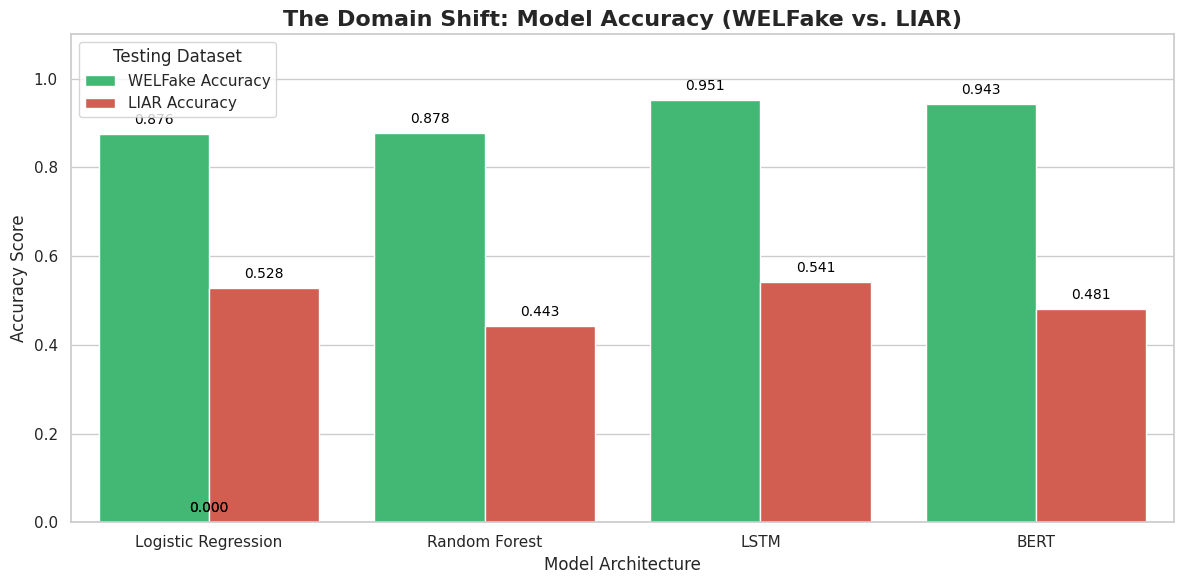

In [37]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

ax1 = sns.barplot(data=df_acc, x="Model", y="Accuracy", hue="Dataset", palette=["#2ecc71", "#e74c3c"])
plt.title("The Domain Shift: Model Accuracy (WELFake vs. LIAR)", fontsize=16, fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel("Accuracy Score", fontsize=12)
plt.xlabel("Model Architecture", fontsize=12)
plt.legend(title="Testing Dataset", loc="upper left")

for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.3f}",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                 textcoords='offset points')

plt.tight_layout()
plt.show()

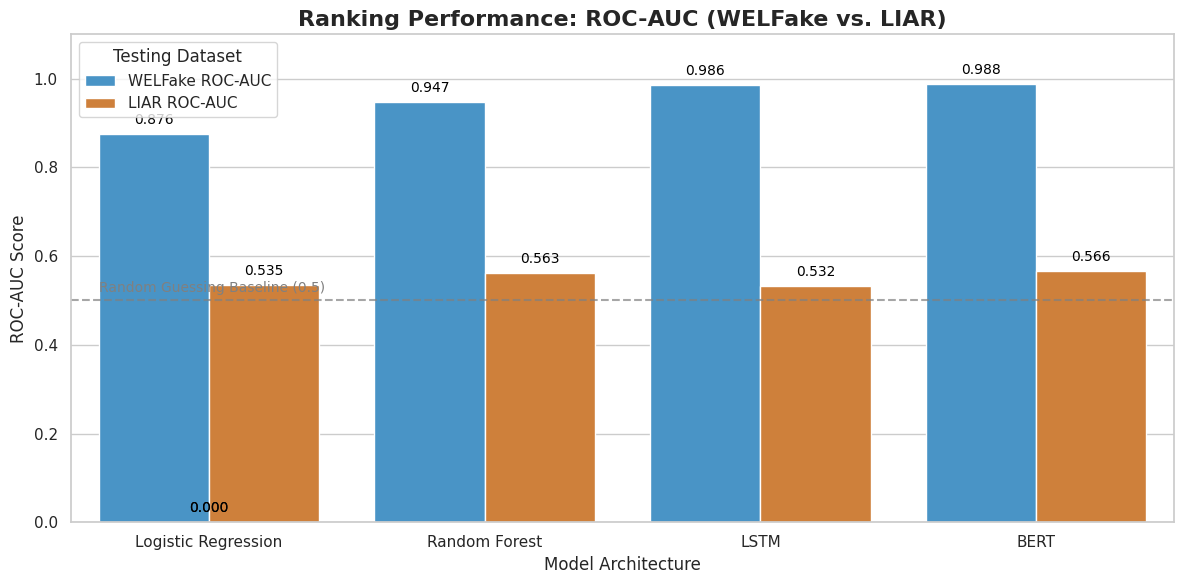

In [38]:
plt.figure(figsize=(12, 6))

ax2 = sns.barplot(data=df_roc, x="Model", y="ROC-AUC", hue="Dataset", palette=["#3498db", "#e67e22"])
plt.title("Ranking Performance: ROC-AUC (WELFake vs. LIAR)", fontsize=16, fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel("ROC-AUC Score", fontsize=12)
plt.xlabel("Model Architecture", fontsize=12)
plt.legend(title="Testing Dataset", loc="upper left")

for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.3f}",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                 textcoords='offset points')

plt.axhline(0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
plt.text(-0.4, 0.52, 'Random Guessing Baseline (0.5)', color='gray', fontsize=10)

plt.tight_layout()
plt.show()